# Step 5 Modeling - Support Vector Machine (SVM) classification


**Created/Updated by:** Naeem

**Goal:** Predict `Depression_Flag` (PHQ-9 >= 10) from demographic, socioeconomic and lifestyle
features only. PHQ-9 itself was already dropped in Step 4 to prevent target leakage.

1. Loads the pre-built train / validation / test splits from Step 4.
2. Removes the survey-design column and redundant duplicate features.
3. Trains a **SVM Classification** model on the standardized split.
5. Tunes parameters  on the **validation** set, then scores the winners **once** on test.
6. Updates the shared scoreboard CSV so CatBoost / XGBoost can be appended later.

**Why the metrics are ordered PR-AUC first:** only ~10.6% of rows are positive.
A model that predicts "not depressed" for everyone already scores 89% accuracy,
so accuracy alone would hide a useless model.

### Imports Libraries

In [49]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

### Configurations

In [33]:
# Folder layout - adjust BASE_DIR only if the notebook is moved out of the project root
BASE_DIR   = "."
SPLIT_DIR  = os.path.join(BASE_DIR, "DataSplit")
MODEL_DIR  = os.path.join(BASE_DIR, "Models")
FIGURE_DIR = os.path.join(BASE_DIR, "Figures")

# Create output folders if they are not there yet
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# One seed for every model so results are reproducible and comparable
RANDOM_STATE = 42

# File name stems for the two encodings this notebook needs
STD_STEM  = "Nhanes_SVM_Logistic"   # one-hot + standardized -> SVM Classification
TARGET_STEM = "Nhanes_Target"       # the y vector, shared by every model

# Shared scoreboard file - CatBoost / XGBoost / SVM notebooks append to this same file
SCOREBOARD_CSV = os.path.join(MODEL_DIR, "rf_logreg_models_scoreboard.csv")

#### Load the splits

Step 4 already produced matched train / validation / test files, so no re-splitting happens here.
Re-splitting would break comparability with the other four models.

In [34]:
# Read one feature file for a given encoding stem and split name
def load_features(stem, split):
    path = os.path.join(SPLIT_DIR, f"{stem}_{split}.csv")
    return pd.read_csv(path, low_memory=False)


# Read the target file for a split and return it as a flat 1-D array
def load_target(split):
    path = os.path.join(SPLIT_DIR, f"{TARGET_STEM}_{split}.csv")
    return pd.read_csv(path)["Depression_Flag"].to_numpy()


# Load the three target vectors once
y_train = load_target("Train")
y_val   = load_target("Val")
y_test  = load_target("Test")

# Quick sanity check on class balance in every split
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:<6} n={len(y):>6}  positives={y.sum():>5}  rate={y.mean():.4f}")

Train  n=  9611  positives= 1020  rate=0.1061
Val    n=  2060  positives=  235  rate=0.1141
Test   n=  2060  positives=  235  rate=0.1141


#### Remove leakage-adjacent and redundant columns

Two clean-up jobs before modeling:

WTMEC_COMB is a survey weight, not a predictor.** It encodes how NHANES sampled the
respondent. Leaving it in lets the trees split on sampling design, which produces feature
importances that mean nothing clinically.

Duplicate-information columns.These inflate Logistic Regression standard errors and
split Random Forest importance across twin columns.

Drop - RIDRETH1 Same race/ethnicity variable, RETH3 is the finer recode 

Drop -INDFMMPI and  INDFMMPC, All three are poverty-income ratio variants 

Drop - ALQ142  measure drinking frequency 


In [35]:
# Columns dropped by exact name
DROP_EXACT = ["WTMEC_COMB"]

# Columns dropped by prefix, because one-hot encoding turned each one into many dummy columns
DROP_PREFIX = ["RIDRETH1_", "INDFMMPI", "INDFMMPC_", "ALQ142_"]


# Return a copy of the dataframe with the survey weight and redundant features removed
def drop_unwanted_columns(df):
    to_drop = [c for c in df.columns if c in DROP_EXACT]
    to_drop += [c for c in df.columns if any(c.startswith(p) for p in DROP_PREFIX)]
    return df.drop(columns=sorted(set(to_drop)))


# Load an encoding stem for all three splits and apply the same column clean-up to each
def load_clean_split(stem):
    train = drop_unwanted_columns(load_features(stem, "Train"))
    val   = drop_unwanted_columns(load_features(stem, "Val"))
    test  = drop_unwanted_columns(load_features(stem, "Test"))

    # Guard: all three splits must end up with identical columns in identical order
    if not (list(train.columns) == list(val.columns) == list(test.columns)):
        raise ValueError(f"Column mismatch across splits for {stem}")

    return train, val, test


# Standardized data for SVM Classification
X_train_std, X_val_std, X_test_std = load_clean_split(STD_STEM)


print(f"SVM features: {X_train_std.shape[1]}")
print(f"Dropped:  {sorted(set(load_features(STD_STEM, 'Train').columns) - set(X_train_std.columns))}")

print(X_train_std.shape)

SVM features: 54
Dropped:  ['ALQ142_-1.0', 'ALQ142_0.0', 'ALQ142_1.0', 'ALQ142_10.0', 'ALQ142_2.0', 'ALQ142_3.0', 'ALQ142_4.0', 'ALQ142_5.0', 'ALQ142_6.0', 'ALQ142_7.0', 'ALQ142_8.0', 'ALQ142_9.0', 'INDFMMPC_-1.0', 'INDFMMPC_1.0', 'INDFMMPC_2.0', 'INDFMMPC_3.0', 'INDFMMPI', 'RIDRETH1_1.0', 'RIDRETH1_2.0', 'RIDRETH1_3.0', 'RIDRETH1_4.0', 'RIDRETH1_5.0', 'WTMEC_COMB']
(9611, 54)


#### Shared evaluation helpers

Every model in the project goes through these two helpers, so the comparison table is
apples-to-apples. The `Scoreboard` class is the only class in this notebook - it exists purely
to hold results and write them to one shared CSV.

In [36]:
# Score a fitted model on one dataset and return a single row of metrics
def score_model(model, X, y, threshold=0.5):
    # Predicted probability of the positive class
    proba = model.predict_proba(X)[:, 1]

    # Hard labels using the chosen decision threshold
    pred = (proba >= threshold).astype(int)

    return {
        "PR_AUC":    average_precision_score(y, proba),
        "ROC_AUC":   roc_auc_score(y, proba),
        "Recall":    recall_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "F1":        f1_score(y, pred, zero_division=0),
        "Accuracy":  accuracy_score(y, pred),
        "Threshold": threshold,
    }


# Collects metric rows from every model so the team can compare them in one table
class Scoreboard:

    # Start an empty results list
    def __init__(self):
        self._rows = []

    # Record one result row, tagged with the model name and which split it came from
    def add(self, model_name, split, metrics):
        if not model_name:
            raise ValueError("model_name is required")
        row = {"Model": model_name, "Split": split}
        row.update(metrics)
        self._rows.append(row)

    # Return the collected results as a dataframe sorted by PR-AUC
    def to_frame(self):
        if not self._rows:
            raise ValueError("Scoreboard is empty - add results before exporting")
        return pd.DataFrame(self._rows).sort_values(
            ["Split", "PR_AUC"], ascending=[True, False]
        ).reset_index(drop=True)

    # Append the results to the shared project CSV, replacing this notebook's own old rows
    def save(self, path):
        new = self.to_frame()
        if os.path.exists(path):
            old = pd.read_csv(path)
            old = old[~old["Model"].isin(new["Model"].unique())]
            new = pd.concat([old, new], ignore_index=True)
        new.to_csv(path, index=False)
        return new


# One scoreboard instance for this notebook
board = Scoreboard()

####  Modeling - SVM Classification

Uses the **standardized** split. 

- `class_weight="balanced"` offsets the 10.6% positive rate.
- We tune `kernel` (type of function determining similarity between instances)
- Depending on the `kernel`, we tune on combinations of:
    * `C` (the inverse regularization strength, all kernels),
    * `gamma` (range of influence of training examples, all kernels except linear),
    * `degree` (only when `kernel`='poly')

In [43]:
param_grid = [
    # 1. Linear: 7 models only on C
    {
        'kernel': ['linear'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    # 2. RBF & Sigmoid: 7 * 8 * 2 = 112 models on C and gamma and 2 kernel types
    {
        'kernel': ['rbf', 'sigmoid'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1, 10]
    },
    # 3. Poly: 7 * 8 * 4 = 224 models on C, gamma, and degree
    {
        'kernel': ['poly'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1, 10],
        'degree': [2, 3, 4, 5]
    }
]

scoring_metrics = scoring_metrics = {
    'PR_AUC': 'average_precision',
    'ROC_AUC': 'roc_auc',
    'ACCURACY': 'accuracy',
    'PRECISION': 'precision',
    'RECALL': 'recall',
    'F1': 'f1'
}

#Combine features/targets for training and validation sets
X_notest = np.vstack((X_train_std,X_val_std))
y_notest = np.concatenate((y_train,y_val))

#define split index
split_index = [-1]*len(X_train_std)+[0]*len(X_val_std)
pds = PredefinedSplit(test_fold=split_index)

grid_search = GridSearchCV(
    estimator=SVC(class_weight='balanced',random_state=42,max_iter=20000),
    param_grid=param_grid,
    cv=pds,            # validates on calculated split between training and validation sets
    n_jobs=-1,       # Parallelize across all CPU cores
    scoring=scoring_metrics,
    refit='PR_AUC'
    
)

In [44]:
grid_search.fit(X_notest, y_notest)


,estimator,SVC(class_wei...ndom_state=42)
,param_grid,"[{'C': [0.001, 0.01, ...], 'kernel': ['linear']}, {'C': [0.001, 0.01, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf', 'sigmoid']}, ...]"
,scoring,"{'ACCURACY': 'accuracy', 'F1': 'f1', 'PRECISION': 'precision', 'PR_AUC': 'average_precision', ...}"
,n_jobs,-1
,refit,'PR_AUC'
,cv,"PredefinedSpl...ape=(11671,)))"
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [64]:
best_model = grid_search.best_estimator_
best_svm_params = grid_search.best_params_
calibrated_model = CalibratedClassifierCV(best_model,cv='prefit')
calibrated_model.fit(X_train_std,y_train)
calibrated_score = score_model(calibrated_model,X_val_std,y_val)

metrics = pd.DataFrame(calibrated_score,index=([0]))

display(metrics)
print(f"\nBest SVM settings: {best_svm_params}")

,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,0.274944,0.754378,0.021277,0.208333,0.03861,0.879126,0.5



Best SVM settings: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}


In [ ]:
#record validation performance on shared 
board.add("SVM","Validation",calibrated_score)

#### Feature importance - permutation

The built-in `feature_importances_` is biased toward features with many split points, and
`ALQ121` alone became 11 dummy columns. Permutation importance measured on the **validation**
set answers the honest question: how much does validation performance drop if this one
column is shuffled?

In [68]:
perm = permutation_importance(
    calibrated_model,
    X_val_std,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance = pd.DataFrame({
    "Feature": X_val_std.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std,
}).sort_values("Importance_Mean", ascending=False).reset_index(drop=True)

print("Top 15 features by permutation importance")
display(importance.head(15).round(5))

Top 15 features by permutation importance


,Feature,Importance_Mean,Importance_Std
0,INDFMPIR,0.01872,0.00942
1,ALQ151_1.0,0.01556,0.00412
2,RIDAGEYR,0.01438,0.00397
3,DMDMARTZ_-1.0,0.01359,0.00187
4,DMDEDUC2_-1.0,0.01335,0.00318
5,ALQ130,0.01145,0.00254
6,DMDEDUC2_1.0,0.00973,0.00438
7,PAD680,0.00864,0.00404
8,SLD013,0.00832,0.00201
9,DMDMARTZ_3.0,0.00793,0.00294


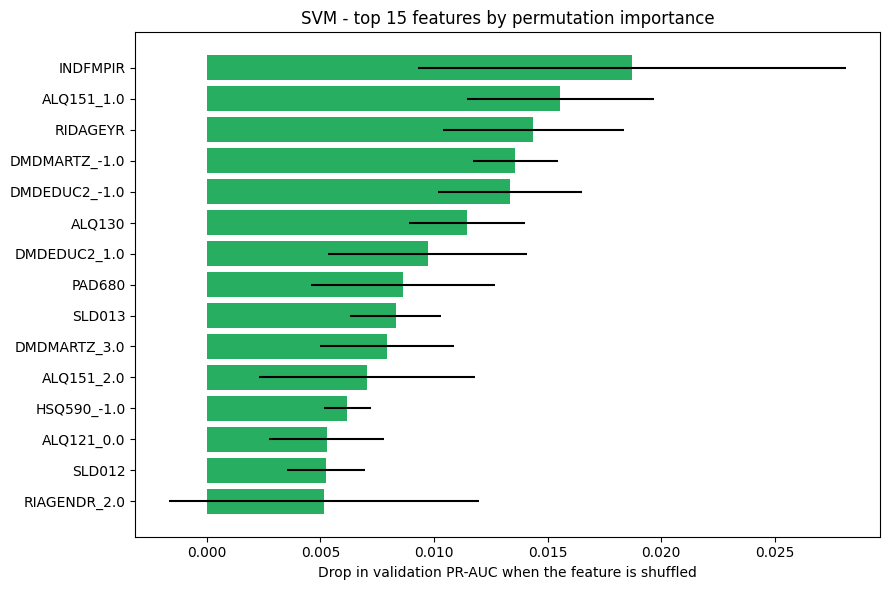

In [70]:
# Plot the 15 most important features
top_importance = importance.head(15).sort_values("Importance_Mean")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top_importance["Feature"],
    top_importance["Importance_Mean"],
    xerr=top_importance["Importance_Std"],
    color="#27ae60",
)
ax.set_xlabel("Drop in validation PR-AUC when the feature is shuffled")
ax.set_title("SVM - top 15 features by permutation importance")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "4_3_svm_permutation_importance.png"), dpi=150)
plt.show()

#### Threshold tuning

The default 0.5 cut-off is arbitrary for imbalanced data. Here we pick the threshold that
maximizes F1 **on the validation set**, then reuse that exact number on test.

Note for the write-up: in a screening context, recall usually matters more than precision -
missing a depressed respondent is worse than flagging someone for a follow-up question.
The team can swap the objective from F1 to "highest precision at recall >= 0.70" if desired.

In [71]:
# Search the precision-recall curve for the threshold with the best F1 score
def best_f1_threshold(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y, proba)

    # The curve returns one more precision/recall point than thresholds, so trim the last one
    precision, recall = precision[:-1], recall[:-1]

    # Guard against a zero denominator when precision and recall are both zero
    denominator = np.where((precision + recall) == 0, 1e-9, precision + recall)
    f1_scores = 2 * precision * recall / denominator

    return float(thresholds[int(np.argmax(f1_scores))])

# Tune each model's threshold on validation only
svm_threshold = best_f1_threshold(calibrated_model, X_val_std, y_val)

print(f"Logistic Regression tuned threshold: {svm_threshold:.4f}")


Logistic Regression tuned threshold: 0.1706


#### Final test evaluation

This is the **only** place the test set is touched. Nothing above this cell used it.

In [73]:
# Score both winning models on the held-out test set using their tuned thresholds
svm_test = score_model(calibrated_model, X_test_std, y_test, threshold=svm_threshold)


board.add("SVM", "Test", svm_test)

# Show the full comparison table, PR-AUC first because of class imbalance
results = board.to_frame()
display(results.round(4))

,Model,Split,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,SVM,Test,0.2580,0.6795,0.4638,0.2577,0.3313,0.7864,0.1706
1,SVM,Validation,0.2749,0.7544,0.0213,0.2083,0.0386,0.8791,0.5000


In [74]:
# Print a confusion matrix and full classification report for each model
def report_model(name, model, X, y, threshold):
    pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int)
    print(f"\n{'=' * 60}\n{name} - test set (threshold {threshold:.3f})\n{'=' * 60}")
    print(pd.DataFrame(
        confusion_matrix(y, pred),
        index=["Actual: No", "Actual: Yes"],
        columns=["Pred: No", "Pred: Yes"],
    ))
    print()
    print(classification_report(y, pred, target_names=["No depression", "Depression"], digits=3))


report_model("SVM Classification", calibrated_model, X_test_std, y_test, svm_threshold)


SVM Classification - test set (threshold 0.171)
             Pred: No  Pred: Yes
Actual: No       1511        314
Actual: Yes       126        109

               precision    recall  f1-score   support

No depression      0.923     0.828     0.873      1825
   Depression      0.258     0.464     0.331       235

     accuracy                          0.786      2060
    macro avg      0.590     0.646     0.602      2060
 weighted avg      0.847     0.786     0.811      2060



#### Save models and results

The scoreboard CSV is shared. When the CatBoost, XGBoost and RandomForest notebooks call
`Scoreboard.save(SCOREBOARD_CSV)`, their rows are appended to the same table and the
final report can read one file.

In [ ]:
# Persist both fitted models with their tuned thresholds and column order
joblib.dump(
    {"model": calibrated_model, "threshold": svm_threshold, "columns": list(X_train_std.columns), "params": best_svm_params},
    os.path.join(MODEL_DIR, "svm_seed42.joblib"),
)

# Write the shared scoreboard
final_board = board.save(SCOREBOARD_CSV)

# Save the interpretation tables for the written report
importance.to_csv(os.path.join(MODEL_DIR, "svm_permutation_importance.csv"), index=False)

print("Saved:")
print(f"  {MODEL_DIR}/svm_seed42.joblib")
print(f"  {MODEL_DIR}/svm_permutation_importance.csv")
print(f"  {SCOREBOARD_CSV}")
display(final_board.round(4))

Saved:
  .\Models/svm_seed42.joblib
  .\Models\rf_logreg_models_scoreboard.csv


,Model,Split,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,LogisticRegression,Test,0.2444,0.6781,0.4255,0.2415,0.3082,0.7820,0.6275
1,RandomForest,Test,0.2327,0.6736,0.3277,0.2232,0.2655,0.7932,0.5338
2,RandomForest,Validation,0.2437,0.7153,0.4596,0.2512,0.3248,0.7820,0.5000
3,LogisticRegression,Validation,0.2342,0.7041,0.6426,0.1979,0.3026,0.6621,0.5000
4,SVM,Test,0.2580,0.6795,0.4638,0.2577,0.3313,0.7864,0.1706
5,SVM,Validation,0.2749,0.7544,0.0213,0.2083,0.0386,0.8791,0.5000
